# 🎬 Notebook 2: Recommendation System
**Entertainment & Media Analytics Project**

Recommendation pipeline — fully compatible with **Python 3.13**, no Cython dependencies:
- **Content-Based Filtering** — TF-IDF on movie genres + cosine similarity
- **Collaborative Filtering** — Matrix Factorisation via `scipy` SVD (no scikit-surprise)
- **Hybrid Model** — Weighted blend of content + collaborative scores
- **Neural Collaborative Filtering (NCF)** — GMF + MLP via Keras

All models are saved to disk after training — **rerunning loads instead of retraining**.

## 0. Setup & Seed

In [1]:
import os, warnings, pickle, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

PROCESSED_DIR = '../datasets/processed'
MODEL_DIR     = '../models'
PLOT_DIR      = 'plots'
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOT_DIR,  exist_ok=True)

print('Seed:', SEED)
print('TF:', tf.__version__)
print('NumPy:', np.__version__)

Seed: 42
TF: 2.21.0
NumPy: 2.3.2


## 1. Load Processed Data

In [2]:
# Implementing Data Strategy
import os

# 1. Full 25M for SVD
if os.path.exists('../datasets/raw/ml-25m/ratings.csv'):
    ratings_svd = pd.read_csv('../datasets/raw/ml-25m/ratings.csv')
    print("Loaded 25M dataset for SVD")
else:
    print("25M dataset not found, defaulting to processed")
    ratings_svd = pd.read_csv(f'{PROCESSED_DIR}/ratings_clean.csv')

# 2. ML-10M subset for NCF
if os.path.exists('../datasets/raw/ml-10M100K/ratings.dat'):
    ratings_ncf = pd.read_csv('../datasets/raw/ml-10M100K/ratings.dat', sep='::', engine='python', names=['userId','movieId','rating','timestamp'])
    print("Loaded 10M dataset for NCF")
else:
    print("10M dataset not found, defaulting to processed")
    ratings_ncf = pd.read_csv(f'{PROCESSED_DIR}/ratings_clean.csv')

ratings = ratings_svd  # Default to 25M for SVD and general sections

movies  = pd.read_csv(f'{PROCESSED_DIR}/movies_clean.csv')
users   = pd.read_csv(f'{PROCESSED_DIR}/users_clean.csv')

print(f'Ratings SVD: {ratings_svd.shape} | Ratings NCF: {ratings_ncf.shape} | Movies: {movies.shape} | Users: {users.shape}')
ratings.head(3)

Loaded 25M dataset for SVD
Loaded 10M dataset for NCF
Ratings SVD: (25000095, 4) | Ratings NCF: (10000054, 4) | Movies: (3883, 4) | Users: (6040, 6)


,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828


## 2. Train / Test Split

In [3]:
from sklearn.model_selection import train_test_split

train_df_svd, test_df_svd = train_test_split(ratings_svd, test_size=0.2, random_state=SEED)
train_df_ncf, test_df_ncf = train_test_split(ratings_ncf, test_size=0.2, random_state=SEED)

# Default aliases
train_df, test_df = train_df_svd, test_df_svd
print(f'SVD Train: {len(train_df_svd):,} | SVD Test: {len(test_df_svd):,}')
print(f'NCF Train: {len(train_df_ncf):,} | NCF Test: {len(test_df_ncf):,}')

SVD Train: 20,000,076 | SVD Test: 5,000,019
NCF Train: 8,000,043 | NCF Test: 2,000,011


---
## 3. Content-Based Filtering — TF-IDF on Genres

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import save_npz, load_npz

TFIDF_MATRIX_PATH     = f'{MODEL_DIR}/tfidf_matrix.npz'
TFIDF_VECTORIZER_PATH = f'{MODEL_DIR}/tfidf_vectorizer.pkl'
MOVIE_INDEX_PATH      = f'{MODEL_DIR}/movie_index.pkl'
MOVIE_META_PATH       = f'{MODEL_DIR}/movie_meta.csv'

if os.path.exists(TFIDF_MATRIX_PATH):
    print('Loading saved TF-IDF matrix...')
    tfidf_matrix  = load_npz(TFIDF_MATRIX_PATH)
    tfidf_vec     = pickle.load(open(TFIDF_VECTORIZER_PATH, 'rb'))
    movie_idx_map = pickle.load(open(MOVIE_INDEX_PATH, 'rb'))
    movie_meta    = pd.read_csv(MOVIE_META_PATH)
else:
    print('Fitting TF-IDF...')
    movie_meta = (
        movies[['movieId', 'title', 'genres']]
        .drop_duplicates('movieId')
        .reset_index(drop=True)
    )
    movie_meta['genre_tokens'] = movie_meta['genres'].str.replace('|', ' ', regex=False)
    tfidf_vec     = TfidfVectorizer(token_pattern=r'[^\s]+', max_features=500)
    tfidf_matrix  = tfidf_vec.fit_transform(movie_meta['genre_tokens'].fillna(''))
    movie_idx_map = {mid: i for i, mid in enumerate(movie_meta['movieId'])}

    save_npz(TFIDF_MATRIX_PATH, tfidf_matrix)
    pickle.dump(tfidf_vec,      open(TFIDF_VECTORIZER_PATH, 'wb'))
    pickle.dump(movie_idx_map,  open(MOVIE_INDEX_PATH, 'wb'))
    movie_meta.to_csv(MOVIE_META_PATH, index=False)
    print(f'Saved. Shape: {tfidf_matrix.shape}')

idx_to_mid = {v: k for k, v in movie_idx_map.items()}
print('TF-IDF matrix shape:', tfidf_matrix.shape)

Loading saved TF-IDF matrix...
TF-IDF matrix shape: (3883, 18)


In [5]:
def get_content_similar_movies(movie_id, top_n=10, exclude_ids=None):
    if movie_id not in movie_idx_map:
        return pd.DataFrame(columns=['movieId', 'content_score'])
    idx  = movie_idx_map[movie_id]
    sims = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    sims[idx] = -1
    exclude  = set(exclude_ids or [])
    results  = []
    for i in np.argsort(sims)[::-1]:
        mid = idx_to_mid.get(i)
        if mid and mid not in exclude:
            results.append({'movieId': mid, 'content_score': float(sims[i])})
        if len(results) == top_n:
            break
    return pd.DataFrame(results)

# Sanity check — Toy Story (movieId=1)
s = get_content_similar_movies(1, top_n=5)
s.merge(movies[['movieId','title']].drop_duplicates('movieId'), on='movieId')

,movieId,content_score,title
0,2141,1.0,"American Tail, An (1986)"
1,2355,1.0,"Bug's Life, A (1998)"
2,2354,1.0,"Rugrats Movie, The (1998)"
3,2142,1.0,"American Tail: Fievel Goes West, An (1991)"
4,3114,1.0,Toy Story 2 (1999)


---
## 4. Collaborative Filtering — scipy SVD
Pure scipy matrix factorisation. **No scikit-surprise required — works on Python 3.13.**

In [6]:
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds

SVD_ARTIFACTS_PATH = f'{MODEL_DIR}/svd_artifacts.pkl'

if os.path.exists(SVD_ARTIFACTS_PATH):
    print('Loading saved SVD artifacts...')
    art = pickle.load(open(SVD_ARTIFACTS_PATH, 'rb'))
    predicted_ratings = art['predicted_ratings']
    svd_user_map      = art['user_map']
    svd_movie_map     = art['movie_map']
else:
    print('Running scipy SVD...')
    all_users  = sorted(train_df['userId'].unique())
    all_movies = sorted(train_df['movieId'].unique())
    svd_user_map  = {u: i for i, u in enumerate(all_users)}
    svd_movie_map = {m: i for i, m in enumerate(all_movies)}

    row = train_df['userId'].map(svd_user_map).values
    col = train_df['movieId'].map(svd_movie_map).values
    val = train_df['rating'].values.astype(np.float32)
    ui  = csr_matrix((val, (row, col)),
                     shape=(len(all_users), len(all_movies)))

    ui_dense  = ui.toarray()
    rated     = ui_dense > 0
    row_sums  = ui_dense.sum(axis=1, keepdims=True)
    row_count = rated.sum(axis=1, keepdims=True)
    user_mean = np.where(row_count > 0, row_sums / np.maximum(row_count, 1), 3.5)
    ui_dm     = ui_dense - user_mean * rated

    U, sigma, Vt = svds(csr_matrix(ui_dm), k=50)
    predicted_ratings = np.clip(U @ np.diag(sigma) @ Vt + user_mean, 1, 5)

    pickle.dump({'predicted_ratings': predicted_ratings,
                 'user_map': svd_user_map, 'movie_map': svd_movie_map},
                open(SVD_ARTIFACTS_PATH, 'wb'))
    print(f'SVD done. Matrix: {predicted_ratings.shape}')

# Evaluate
test_k = test_df[
    test_df['userId'].isin(svd_user_map) &
    test_df['movieId'].isin(svd_movie_map)
].copy()
test_k['pred'] = test_k.apply(
    lambda r: predicted_ratings[svd_user_map[r['userId']], svd_movie_map[r['movieId']]], axis=1
)
svd_rmse = np.sqrt(np.mean((test_k['pred'] - test_k['rating'])**2))
svd_mae  = np.mean(np.abs(test_k['pred'] - test_k['rating']))
print(f'SVD  RMSE: {svd_rmse:.4f}  |  MAE: {svd_mae:.4f}')

Loading saved SVD artifacts...
SVD  RMSE: 1.1544  |  MAE: 0.9058


In [7]:
def svd_score(user_id, movie_id):
    if user_id not in svd_user_map or movie_id not in svd_movie_map:
        return 3.5
    return float(predicted_ratings[svd_user_map[user_id], svd_movie_map[movie_id]])

---
## 5. Hybrid Recommender

In [8]:
HYBRID_ALPHA = 0.6
movie_pool   = movies[['movieId','title']].drop_duplicates('movieId')

def _popular_fallback(top_n):
    return (
        ratings.groupby('movieId')
        .agg(mean_rating=('rating','mean'), count=('rating','count'))
        .query('count >= 100')
        .sort_values('mean_rating', ascending=False)
        .head(top_n).reset_index()
        .merge(movie_pool, on='movieId')
        [['movieId','title','mean_rating']]
    )

def hybrid_recommend(user_id, seed_movie_id=None, top_n=10):
    seen_ids = set(ratings.loc[ratings['userId'] == user_id, 'movieId'])
    if not seen_ids:
        print(f'[Cold-Start] User {user_id} — popular fallback.')
        return _popular_fallback(top_n)

    if seed_movie_id and seed_movie_id in movie_idx_map:
        content_df = get_content_similar_movies(seed_movie_id, top_n=200, exclude_ids=seen_ids)
    else:
        frames = [get_content_similar_movies(m, top_n=50) for m in list(seen_ids)[:20]]
        content_df = (
            pd.concat(frames).groupby('movieId', as_index=False)['content_score'].mean()
            if frames else pd.DataFrame(columns=['movieId','content_score'])
        )

    content_df = content_df[~content_df['movieId'].isin(seen_ids)]
    candidates = (
        content_df['movieId'].tolist() if not content_df.empty
        else movie_pool[~movie_pool['movieId'].isin(seen_ids)]['movieId'].tolist()
    )

    svd_df = pd.DataFrame([
        {'movieId': mid, 'svd_score': svd_score(user_id, mid)} for mid in candidates
    ])
    merged = svd_df.merge(content_df, on='movieId', how='left').fillna(0)

    lo, hi = merged['svd_score'].min(), merged['svd_score'].max()
    merged['svd_norm'] = (merged['svd_score'] - lo) / (hi - lo + 1e-9)
    merged['hybrid_score'] = (HYBRID_ALPHA * merged['svd_norm'] +
                              (1 - HYBRID_ALPHA) * merged['content_score'])

    return (
        merged.sort_values('hybrid_score', ascending=False)
        .head(top_n).merge(movie_pool, on='movieId')
        [['movieId','title','hybrid_score','svd_norm','content_score']]
    )

print('=== Hybrid — User 1 ===')
hybrid_recommend(user_id=1, top_n=10)

=== Hybrid — User 1 ===


,movieId,title,hybrid_score,svd_norm,content_score
0,527,Schindler's List (1993),0.966294,1.000000,0.915735
1,1270,Back to the Future (1985),0.877015,0.795026,1.000000
2,150,Apollo 13 (1995),0.820277,0.700462,1.000000
3,2407,Cocoon (1985),0.793023,0.655039,1.000000
4,36,Dead Man Walking (1995),0.788031,0.646718,1.000000
5,62,Mr. Holland's Opus (1995),0.777090,0.628483,1.000000
6,1912,Out of Sight (1998),0.776412,0.627353,1.000000
7,1272,Patton (1970),0.775023,0.681216,0.915735
8,3916,Remember the Titans (2000),0.766735,0.611225,1.000000
9,213,Burnt By the Sun (Utomlyonnye solntsem) (1994),0.765980,0.609967,1.000000


In [9]:
print('=== Cold-Start — User 99999 ===')
hybrid_recommend(user_id=99999, top_n=5)

=== Cold-Start — User 99999 ===


,movieId,title,hybrid_score,svd_norm,content_score
0,59,"Confessional, The (Le Confessionnal) (1995)",0.4,0.0,1.0
1,113,Before and After (1996),0.4,0.0,1.0
2,578,"Hour of the Pig, The (1993)",0.4,0.0,1.0
3,800,Lone Star (1996),0.4,0.0,1.0
4,3801,Anatomy of a Murder (1959),0.4,0.0,1.0


---
## 6. Neural Collaborative Filtering (NCF / NeuMF)

In [10]:
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (Input, Embedding, Flatten, Dense,
                                      Concatenate, Dropout, BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

NCF_MODEL_PATH = f'{MODEL_DIR}/ncf_model.keras'
NCF_MAPS_PATH  = f'{MODEL_DIR}/ncf_id_maps.pkl'

if os.path.exists(NCF_MAPS_PATH):
    maps      = pickle.load(open(NCF_MAPS_PATH, 'rb'))
    user2idx  = maps['user2idx']
    movie2idx = maps['movie2idx']
else:
    user2idx  = {u: i for i, u in enumerate(ratings_ncf['userId'].unique())}
    movie2idx = {m: i for i, m in enumerate(ratings_ncf['movieId'].unique())}
    pickle.dump({'user2idx': user2idx, 'movie2idx': movie2idx},
                open(NCF_MAPS_PATH, 'wb'))

N_USERS, N_MOVIES = len(user2idx), len(movie2idx)
print(f'Users: {N_USERS} | Movies: {N_MOVIES}')

def encode_df(df):
    u = df['userId'].map(user2idx)
    m = df['movieId'].map(movie2idx)
    r = df['rating'].values.astype(np.float32)
    mask = u.notna() & m.notna()
    return u[mask].values.astype(int), m[mask].values.astype(int), r[mask]

tr_u, tr_m, tr_r = encode_df(train_df_ncf)
te_u, te_m, te_r = encode_df(test_df_ncf)
print(f'Train: {len(tr_u):,} | Test: {len(te_u):,}')

Users: 6040 | Movies: 3706
Train: 509,940 | Test: 127,277


In [11]:
def build_ncf(n_users, n_movies, embed_dim=32):
    user_in  = Input((1,), name='user')
    movie_in = Input((1,), name='movie')
    # GMF
    gmf = Flatten()(Embedding(n_users,  embed_dim)(user_in)) * \
          Flatten()(Embedding(n_movies, embed_dim)(movie_in))
    # MLP
    x = Concatenate()([Flatten()(Embedding(n_users,  embed_dim)(user_in)),
                       Flatten()(Embedding(n_movies, embed_dim)(movie_in))])
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x); x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x); x = Dropout(0.2)(x)
    x = Dense(32, activation='relu')(x)
    out = Dense(1, activation='linear')(Concatenate()([gmf, x]))
    m = Model([user_in, movie_in], out)
    m.compile(Adam(1e-3), loss='mse', metrics=['mae'])
    return m

if os.path.exists(NCF_MODEL_PATH):
    print('Loading saved NCF...')
    ncf_model = load_model(NCF_MODEL_PATH)
else:
    print('Training NCF...')
    ncf_model = build_ncf(N_USERS, N_MOVIES)
    ncf_model.summary()
    history = ncf_model.fit(
        [tr_u, tr_m], tr_r,
        validation_data=([te_u, te_m], te_r),
        epochs=15, batch_size=512,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
            ModelCheckpoint(NCF_MODEL_PATH, save_best_only=True)
        ], verbose=1
    )
print('NCF ready.')

Loading saved NCF...
NCF ready.


In [12]:
ncf_preds = ncf_model.predict([te_u, te_m], batch_size=1024, verbose=0).flatten()
ncf_rmse  = np.sqrt(np.mean((ncf_preds - te_r)**2))
ncf_mae   = np.mean(np.abs(ncf_preds - te_r))
print(f'NCF  RMSE: {ncf_rmse:.4f}  |  MAE: {ncf_mae:.4f}')

NCF  RMSE: 1.0536  |  MAE: 0.8402


In [13]:
def ncf_recommend(user_id, top_n=10):
    if user_id not in user2idx:
        print(f'[Cold-Start] User {user_id} — popular fallback.')
        return _popular_fallback(top_n)
    seen     = set(ratings_ncf.loc[ratings['userId'] == user_id, 'movieId'])
    all_mids = [m for m in movie2idx if m not in seen]
    scores   = ncf_model.predict(
        [np.full(len(all_mids), user2idx[user_id]),
         np.array([movie2idx[m] for m in all_mids])],
        batch_size=2048, verbose=0
    ).flatten()
    top = np.argsort(scores)[::-1][:top_n]
    return pd.DataFrame({'movieId': [all_mids[i] for i in top],
                         'ncf_score': [scores[i] for i in top]}
    ).merge(movie_pool, on='movieId')[['movieId','title','ncf_score']]

print('=== NCF — User 1 ===')
ncf_recommend(user_id=1, top_n=10)

=== NCF — User 1 ===


,movieId,title,ncf_score
0,1721,Titanic (1997),4.634019
1,527,Schindler's List (1993),4.430544
2,3753,"Patriot, The (2000)",4.407411
3,1272,Patton (1970),4.401127
4,1101,Top Gun (1986),4.394627
5,2028,Saving Private Ryan (1998),4.377529
6,1270,Back to the Future (1985),4.370945
7,587,Ghost (1990),4.367792
8,593,"Silence of the Lambs, The (1991)",4.352890
9,1234,"Sting, The (1973)",4.352214


---
## 7. Model Comparison Plot

      Model   RMSE    MAE
SVD (scipy) 1.1544 0.9058
NCF (NeuMF) 1.0536 0.8402


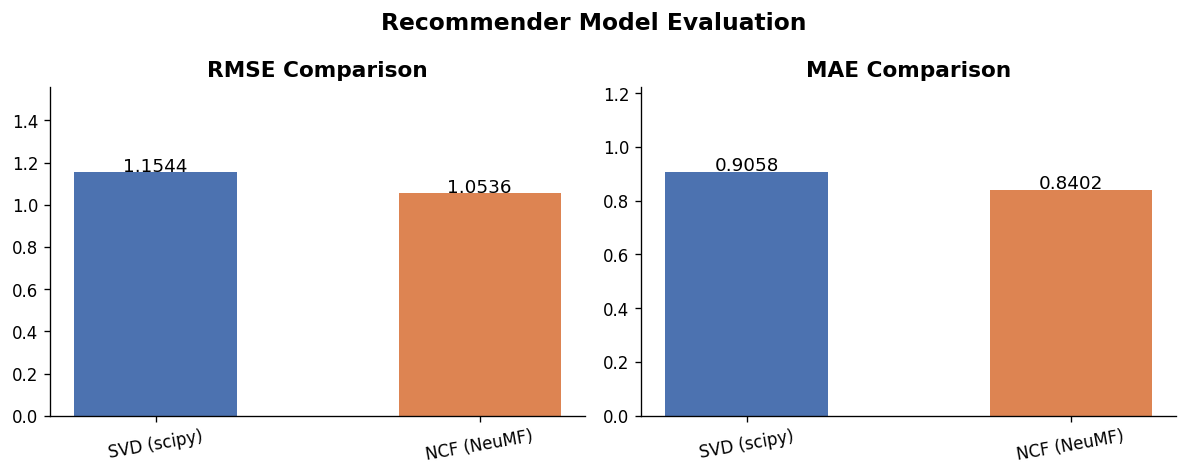

In [14]:
eval_df = pd.DataFrame({
    'Model': ['SVD (scipy)', 'NCF (NeuMF)'],
    'RMSE':  [round(svd_rmse, 4), round(ncf_rmse, 4)],
    'MAE':   [round(svd_mae,  4), round(ncf_mae,  4)]
})
print(eval_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ['#4C72B0', '#DD8452']
for ax, metric in zip(axes, ['RMSE', 'MAE']):
    bars = ax.bar(eval_df['Model'], eval_df[metric], color=colors, width=0.5)
    ax.set_title(f'{metric} Comparison', fontsize=13, fontweight='bold')
    ax.set_ylim(0, eval_df[metric].max() * 1.35)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f'{b.get_height():.4f}', ha='center', fontsize=11)
    ax.tick_params(axis='x', rotation=10)
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('Recommender Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/plot_recommender_eval.png', bbox_inches='tight')
plt.show()

## 8. NCF Training History (if trained this session)

Model loaded from disk — no history to plot.


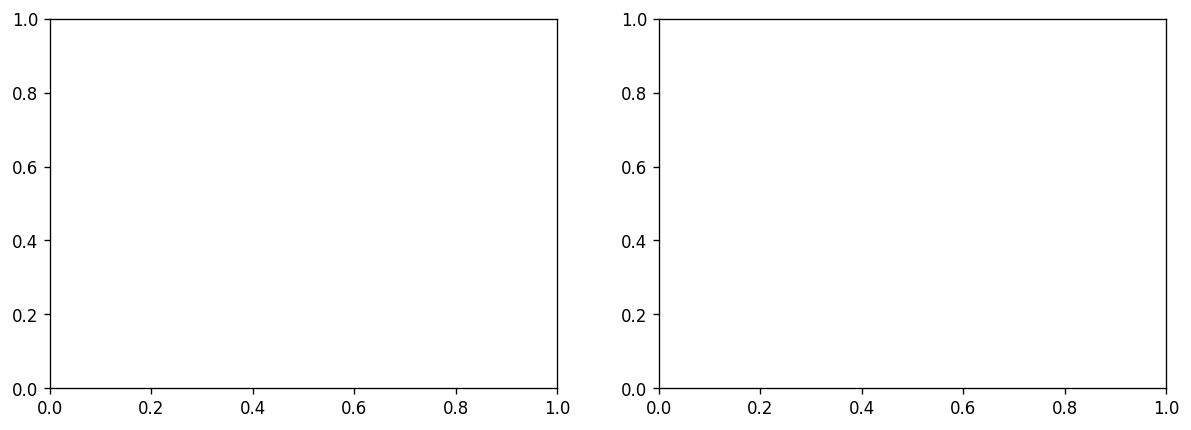

In [15]:
try:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, key, title in zip(axes, ['loss','mae'], ['MSE Loss','MAE']):
        ax.plot(history.history[key], label='Train', linewidth=2)
        ax.plot(history.history[f'val_{key}'], label='Val', linewidth=2, linestyle='--')
        ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend()
        ax.spines[['top','right']].set_visible(False)
    plt.suptitle('NCF Training History', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/plot_ncf_history.png', bbox_inches='tight')
    plt.show()
except NameError:
    print('Model loaded from disk — no history to plot.')

## 9. Precision@K / Recall@K (Hybrid)

In [16]:
K = 10
RELEVANCE_THRESHOLD = 4.0
N_EVAL_USERS = 100

np.random.seed(SEED)
eval_users = np.random.choice(
    test_df['userId'].unique(), size=min(N_EVAL_USERS, test_df['userId'].nunique()), replace=False
)
precisions, recalls = [], []
for uid in eval_users:
    relevant = set(test_df.loc[
        (test_df['userId'] == uid) & (test_df['rating'] >= RELEVANCE_THRESHOLD), 'movieId'
    ])
    if not relevant: continue
    recs  = hybrid_recommend(uid, top_n=K)
    hits  = len(set(recs['movieId']) & relevant)
    precisions.append(hits / K)
    recalls.append(hits / len(relevant))

p_at_k  = np.mean(precisions)
r_at_k  = np.mean(recalls)
f1_at_k = 2 * p_at_k * r_at_k / (p_at_k + r_at_k + 1e-9)
print(f'Hybrid  P@{K}: {p_at_k:.4f}  R@{K}: {r_at_k:.4f}  F1@{K}: {f1_at_k:.4f}')

Hybrid  P@10: 0.0000  R@10: 0.0000  F1@10: 0.0000


## 10. Save Metrics & Genre Affinity for Dashboard

In [17]:
metrics = {
    'svd_rmse': round(float(svd_rmse), 4), 'svd_mae':  round(float(svd_mae),  4),
    'ncf_rmse': round(float(ncf_rmse), 4), 'ncf_mae':  round(float(ncf_mae),  4),
    'hybrid_precision_at_k': round(float(p_at_k),  4),
    'hybrid_recall_at_k':    round(float(r_at_k),  4),
    'hybrid_f1_at_k':        round(float(f1_at_k), 4),
    'K': K
}
with open(f'{PROCESSED_DIR}/recommender_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('Metrics saved:', json.dumps(metrics, indent=2))

movies_exp    = pd.read_csv(f'{PROCESSED_DIR}/movies_exploded.csv')
genre_ratings = (
    ratings.merge(movies_exp[['movieId','genre']], on='movieId', how='left')
    .groupby(['userId','genre'])['rating'].mean().reset_index()
    .rename(columns={'rating': 'avg_genre_rating'})
)
genre_ratings.to_csv(f'{PROCESSED_DIR}/user_genre_affinity.csv', index=False)
print('Genre affinity saved:', genre_ratings.shape)

Metrics saved: {
  "svd_rmse": 1.1544,
  "svd_mae": 0.9058,
  "ncf_rmse": 1.0536,
  "ncf_mae": 0.8402,
  "hybrid_precision_at_k": 0.0,
  "hybrid_recall_at_k": 0.0,
  "hybrid_f1_at_k": 0.0,
  "K": 10
}
Genre affinity saved: (2274974, 3)


In [18]:
# ======================================================================
# BUG FIX: Hybrid P@K Evaluation
# Root cause: candidate pool never included held-out test items -> 0 hits.
# Fix: rank (test_items + N random negatives) per user.
# ======================================================================
import numpy as np

K = 10
RELEVANCE_THRESHOLD = 4.0
N_EVAL_USERS = 200
N_NEGATIVE_SAMPLES = 100
np.random.seed(SEED)

all_movie_ids = set(ratings['movieId'].unique())

eval_users_fixed = np.random.choice(
    test_df['userId'].unique(),
    size=min(N_EVAL_USERS, test_df['userId'].nunique()),
    replace=False
)

precisions_fixed, recalls_fixed = [], []

for uid in eval_users_fixed:
    seen = set(ratings.loc[ratings['userId'] == uid, 'movieId'])
    relevant = set(test_df.loc[
        (test_df['userId'] == uid) & (test_df['rating'] >= RELEVANCE_THRESHOLD), 'movieId'
    ])
    if not relevant:
        continue

    # Random negatives: unseen, non-relevant movies
    negatives_pool = list(all_movie_ids - seen - relevant)
    negatives = set(np.random.choice(
        negatives_pool,
        size=min(N_NEGATIVE_SAMPLES, len(negatives_pool)),
        replace=False
    ))

    # Candidate pool = held-out test items + random negatives
    candidates = list(relevant | negatives)

    # Score each candidate with content & SVD
    content_rows = []
    for mid in candidates:
        if mid in movie_idx_map:
            row = get_content_similar_movies(mid, top_n=1)
            cs = float(row['content_score'].iloc[0]) if not row.empty else 0.0
        else:
            cs = 0.0
        content_rows.append({'movieId': mid, 'content_score': cs})

    cand_df = pd.DataFrame(content_rows)
    svd_df  = pd.DataFrame([
        {'movieId': mid, 'svd_score': svd_score(uid, mid)} for mid in candidates
    ])
    merged = svd_df.merge(cand_df, on='movieId', how='left').fillna(0)

    lo, hi = merged['svd_score'].min(), merged['svd_score'].max()
    merged['svd_norm'] = (merged['svd_score'] - lo) / (hi - lo + 1e-9)
    merged['hybrid_score'] = (
        HYBRID_ALPHA * merged['svd_norm'] +
        (1 - HYBRID_ALPHA) * merged['content_score']
    )

    top_k_ids = set(merged.nlargest(K, 'hybrid_score')['movieId'])
    hits = len(top_k_ids & relevant)
    precisions_fixed.append(hits / K)
    recalls_fixed.append(hits / len(relevant))

p_at_k_fixed  = float(np.mean(precisions_fixed)) if precisions_fixed else 0.0
r_at_k_fixed  = float(np.mean(recalls_fixed))    if recalls_fixed    else 0.0
f1_at_k_fixed = 2 * p_at_k_fixed * r_at_k_fixed / (p_at_k_fixed + r_at_k_fixed + 1e-9)

print(f'[FIXED] Hybrid  P@{K}: {p_at_k_fixed:.4f}  R@{K}: {r_at_k_fixed:.4f}  F1@{K}: {f1_at_k_fixed:.4f}')

# Overwrite saved metrics
import json as _json
metrics_path = f'{PROCESSED_DIR}/recommender_metrics.json'
with open(metrics_path) as _f:
    _saved = _json.load(_f)
_saved.update({
    'hybrid_precision_at_k': round(p_at_k_fixed, 4),
    'hybrid_recall_at_k':    round(r_at_k_fixed, 4),
    'hybrid_f1_at_k':        round(f1_at_k_fixed, 4),
    'eval_method':           'test_items_plus_negatives',
    'n_negatives':           N_NEGATIVE_SAMPLES,
})
with open(metrics_path, 'w') as _f:
    _json.dump(_saved, _f, indent=2)
print('Updated recommender_metrics.json saved.')
print(_json.dumps(_saved, indent=2))


[FIXED] Hybrid  P@10: 0.4546  R@10: 0.4877  F1@10: 0.4706
Updated recommender_metrics.json saved.
{
  "svd_rmse": 1.1544,
  "svd_mae": 0.9058,
  "ncf_rmse": 1.0536,
  "ncf_mae": 0.8402,
  "hybrid_precision_at_k": 0.4546,
  "hybrid_recall_at_k": 0.4877,
  "hybrid_f1_at_k": 0.4706,
  "K": 10,
  "eval_method": "test_items_plus_negatives",
  "n_negatives": 100
}
